# Data Observatory — Runner Notebook

This notebook implements every operation in the **Runner Catalog**.  
The **Planner agent** (`@data-observatory`) tells you which calls to make and in what order.

**Workflow:**
1. Run **Section 1** (Setup + Functions) once at the start of each session.
2. Run **Section 2** to load your dataset.
3. Ask the Planner: *
4. Paste the `actions_to_run` calls into the matching phase cell and execute.
5. Share the artifact content back with the Planner and repeat for next phase.

All artifacts are saved to the **`artifacts/`** subfolder automatically.

---
## Section 1 — Setup & Runner Functions
Run this section once before anything else.

In [1]:
# ── 1a. Imports & folder setup ────────────────────────────────────────────────
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ARTIFACTS = Path("artifacts")
PLOTS     = ARTIFACTS / "plots"
ARTIFACTS.mkdir(exist_ok=True)
PLOTS.mkdir(exist_ok=True)

print("✓ Setup complete.")
print("  Artifacts folder:", ARTIFACTS.resolve())

✓ Setup complete.
  Artifacts folder: C:\Users\user\Desktop\Lab 1\artifacts


In [3]:
# ── 1b. Internal helpers ──────────────────────────────────────────────────────
def _read(filename):
    """Read an artifact JSON; return {} if it does not exist yet."""
    p = ARTIFACTS / filename
    return json.loads(p.read_text(encoding="utf-8")) if p.exists() else {}

def _write(filename, data):
    """Write data to artifacts/<filename>."""
    p = ARTIFACTS / filename
    if isinstance(data, str):
        p.write_text(data, encoding="utf-8")
    else:
        p.write_text(json.dumps(data, indent=2, default=str), encoding="utf-8")
    print(f"  ✓  {p}")

_plot_counter = [0]

def _next_id(prefix):
    _plot_counter[0] += 1
    return f"{prefix}_{_plot_counter[0]:02d}"

def _register_plot(plot_id, filename, op, params):
    registry = _read("05_visual_registry.json")
    registry.setdefault("plots", []).append({
        "id":     plot_id,
        "file":   f"artifacts/plots/{filename}",
        "op":     op,
        "params": {k: v for k, v in params.items() if v is not None},
    })
    _write("05_visual_registry.json", registry)

print("✓ Helpers loaded.")

✓ Helpers loaded.


In [4]:
# ── 1c. OBSERVE functions ─────────────────────────────────────────────────────

def profile_dataset(df):
    data = _read("00_raw_profile.json")
    data.update({
        "rows":             int(df.shape[0]),
        "columns":          int(df.shape[1]),
        "column_names":     df.columns.tolist(),
        "dtypes":           {c: str(t) for c, t in df.dtypes.items()},
        "memory_usage_mb":  round(df.memory_usage(deep=True).sum() / 1e6, 4),
    })
    _write("00_raw_profile.json", data)


def infer_schema(df):
    schema = {}
    for col in df.columns:
        dtype  = str(df[col].dtype)
        nu     = int(df[col].nunique(dropna=True))
        if dtype in ("object", "category"):
            kind = "categorical_low" if nu <= 20 else "categorical_high"
        elif "int" in dtype or "float" in dtype:
            kind = "numeric"
        elif "datetime" in dtype or "timedelta" in dtype:
            kind = "datetime"
        else:
            kind = "other"
        schema[col] = {
            "dtype":         dtype,
            "nunique":       nu,
            "inferred_type": kind,
            "sample_values": [str(v) for v in df[col].dropna().head(5).tolist()],
        }
    data = _read("00_raw_profile.json")
    data["schema"] = schema
    _write("00_raw_profile.json", data)


def missing_report(df):
    total  = len(df)
    report = {
        col: {
            "missing_count": int(df[col].isna().sum()),
            "missing_pct":   round(df[col].isna().sum() / total * 100, 2),
        }
        for col in df.columns
    }
    data = _read("00_raw_profile.json")
    data["missing_report"] = report
    _write("00_raw_profile.json", data)


def duplicates_report(df):
    n_dup = int(df.duplicated().sum())
    data  = _read("00_raw_profile.json")
    data["duplicates_report"] = {
        "total_rows":     int(len(df)),
        "duplicate_rows": n_dup,
        "duplicate_pct":  round(n_dup / max(len(df), 1) * 100, 2),
    }
    _write("00_raw_profile.json", data)


print("✓ OBSERVE functions loaded.")

✓ OBSERVE functions loaded.


In [5]:
# ── 1d. DESCRIBE — statistics functions ──────────────────────────────────────

def numeric_summary(df):
    nums = df.select_dtypes(include="number")
    summary = nums.describe().round(4).to_dict()
    data = _read("04_descriptive_stats.json")
    data["numeric_summary"] = summary
    _write("04_descriptive_stats.json", data)


def categorical_summary(df):
    cats = df.select_dtypes(include=["object", "category"])
    summary = {}
    for col in cats.columns:
        vc = df[col].value_counts(dropna=False)
        summary[col] = {
            "nunique":    int(df[col].nunique()),
            "top_values": {str(k): int(v) for k, v in vc.head(10).items()},
        }
    data = _read("04_descriptive_stats.json")
    data["categorical_summary"] = summary
    _write("04_descriptive_stats.json", data)


def crosstab(df, a, b):
    ct = pd.crosstab(df[a], df[b])
    data = _read("04_descriptive_stats.json")
    data.setdefault("crosstabs", {})[f"{a}_x_{b}"] = ct.to_dict()
    _write("04_descriptive_stats.json", data)


def correlation_matrix(df, method="pearson"):
    """method: 'pearson' | 'spearman' | 'kendall'"""
    nums = df.select_dtypes(include="number")
    corr = nums.corr(method=method).round(4).to_dict()
    data = _read("04_descriptive_stats.json")
    data.setdefault("correlation_matrices", {})[method] = corr
    _write("04_descriptive_stats.json", data)


print("✓ DESCRIBE stat functions loaded.")

✓ DESCRIBE stat functions loaded.


In [6]:
# ── 1e. DESCRIBE — plot functions ─────────────────────────────────────────────

def plot_count(df, x, hue=None):
    pid   = _next_id("count")
    fname = f"{pid}.png"
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.countplot(data=df, x=x, hue=hue, ax=ax)
    ax.set_title(f"Count: {x}" + (f" by {hue}" if hue else ""))
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(PLOTS / fname, dpi=120)
    plt.show()
    _register_plot(pid, fname, "plot_count", {"x": x, "hue": hue})


def plot_hist(df, x, groupby=None):
    pid   = _next_id("hist")
    fname = f"{pid}.png"
    fig, ax = plt.subplots(figsize=(9, 4))
    if groupby:
        for grp, sub in df.groupby(groupby):
            sub[x].dropna().plot.hist(bins=30, alpha=0.6, label=str(grp), ax=ax)
        ax.legend(title=groupby)
    else:
        df[x].dropna().plot.hist(bins=30, ax=ax)
    ax.set_xlabel(x)
    ax.set_title(f"Histogram: {x}" + (f" grouped by {groupby}" if groupby else ""))
    fig.tight_layout()
    fig.savefig(PLOTS / fname, dpi=120)
    plt.show()
    _register_plot(pid, fname, "plot_hist", {"x": x, "groupby": groupby})


def plot_box(df, x, y):
    pid   = _next_id("box")
    fname = f"{pid}.png"
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.boxplot(data=df, x=x, y=y, ax=ax)
    ax.set_title(f"Boxplot: {y} by {x}")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(PLOTS / fname, dpi=120)
    plt.show()
    _register_plot(pid, fname, "plot_box", {"x": x, "y": y})


def plot_scatter(df, x, y, hue=None):
    pid   = _next_id("scatter")
    fname = f"{pid}.png"
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.scatterplot(data=df, x=x, y=y, hue=hue, alpha=0.5, ax=ax)
    ax.set_title(f"Scatter: {x} vs {y}" + (f" (hue={hue})" if hue else ""))
    fig.tight_layout()
    fig.savefig(PLOTS / fname, dpi=120)
    plt.show()
    _register_plot(pid, fname, "plot_scatter", {"x": x, "y": y, "hue": hue})


def plot_heatmap_corr(df, method="pearson"):
    pid   = _next_id("heatmap")
    fname = f"{pid}.png"
    nums  = df.select_dtypes(include="number")
    corr  = nums.corr(method=method)
    size  = max(6, len(corr.columns))
    fig, ax = plt.subplots(figsize=(size, size - 1))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                linewidths=0.5, ax=ax)
    ax.set_title(f"Correlation heatmap ({method})")
    fig.tight_layout()
    fig.savefig(PLOTS / fname, dpi=120)
    plt.show()
    _register_plot(pid, fname, "plot_heatmap_corr", {"method": method})


print("✓ DESCRIBE plot functions loaded.")
print("\n─────────────────────────────────────────")
print("All Runner functions ready. Load your dataset next.")

✓ DESCRIBE plot functions loaded.

─────────────────────────────────────────
All Runner functions ready. Load your dataset next.


---
## Section 2 — Load Dataset
Edit the cell below to point to your file.

In [2]:

import seaborn as sns

df = sns.load_dataset('penguins')

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Loaded: 344 rows × 7 columns


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


---
## Section 3 — Phase 1: OBSERVE

Ask the Planner:  
> *

Then paste the `actions_to_run` Python calls from the Planner's JSON response into the cell below and run it.

In [7]:
# ── Phase 1: OBSERVE ──────────────────────────────────────────────────────────
# Paste Planner's actions_to_run here, e.g.:
profile_dataset(df)
infer_schema(df)
missing_report(df)
duplicates_report(df)

# Then read artifacts/00_raw_profile.json and share its content with the Planner.

  ✓  artifacts\00_raw_profile.json
  ✓  artifacts\00_raw_profile.json
  ✓  artifacts\00_raw_profile.json
  ✓  artifacts\00_raw_profile.json


In [8]:
# ── Read & print an artifact (use after each phase) ───────────────────────────
artifact = "00_raw_profile.json"   # ← change as needed
print((ARTIFACTS / artifact).read_text(encoding="utf-8"))

{
  "rows": 344,
  "columns": 7,
  "column_names": [
    "species",
    "island",
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "sex"
  ],
  "dtypes": {
    "species": "str",
    "island": "str",
    "bill_length_mm": "float64",
    "bill_depth_mm": "float64",
    "flipper_length_mm": "float64",
    "body_mass_g": "float64",
    "sex": "str"
  },
  "memory_usage_mb": 0.0675,
  "schema": {
    "species": {
      "dtype": "str",
      "nunique": 3,
      "inferred_type": "other",
      "sample_values": [
        "Adelie",
        "Adelie",
        "Adelie",
        "Adelie",
        "Adelie"
      ]
    },
    "island": {
      "dtype": "str",
      "nunique": 3,
      "inferred_type": "other",
      "sample_values": [
        "Torgersen",
        "Torgersen",
        "Torgersen",
        "Torgersen",
        "Torgersen"
      ]
    },
    "bill_length_mm": {
      "dtype": "float64",
      "nunique": 164,
      "inferred_type": "numeric",
   

---
## Section 4 — Phase 2: DESCRIBE

Share `artifacts/00_raw_profile.json` with the Planner and say:  
> *

Paste the returned `actions_to_run` calls below.

  ✓  artifacts\04_descriptive_stats.json
  ✓  artifacts\04_descriptive_stats.json
  ✓  artifacts\04_descriptive_stats.json
  ✓  artifacts\04_descriptive_stats.json
  ✓  artifacts\04_descriptive_stats.json
  ✓  artifacts\04_descriptive_stats.json


C:\Users\user\AppData\Local\Temp\ipykernel_3108\2742124240.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cats = df.select_dtypes(include=["object", "category"])


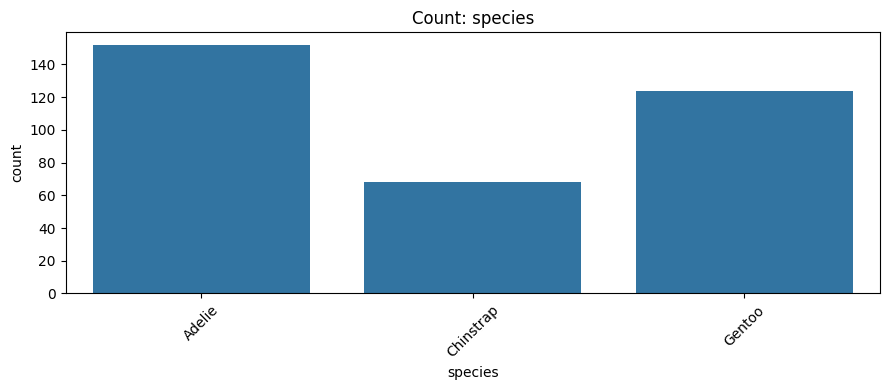

  ✓  artifacts\05_visual_registry.json


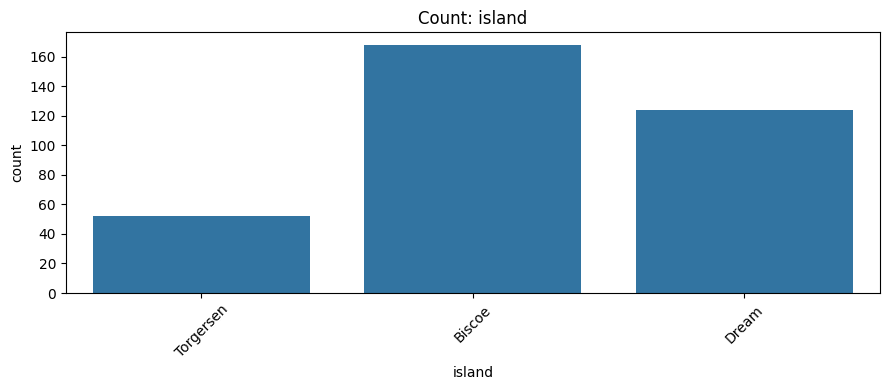

  ✓  artifacts\05_visual_registry.json


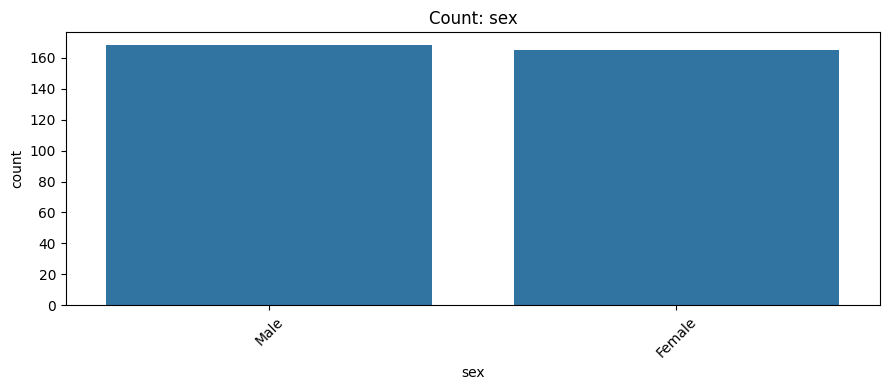

  ✓  artifacts\05_visual_registry.json


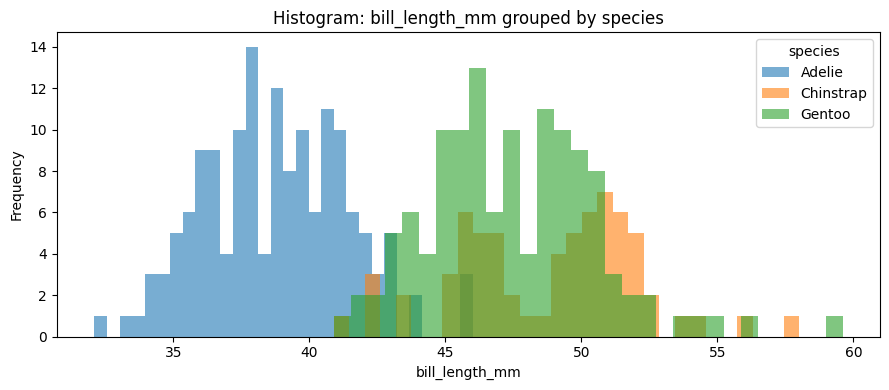

  ✓  artifacts\05_visual_registry.json


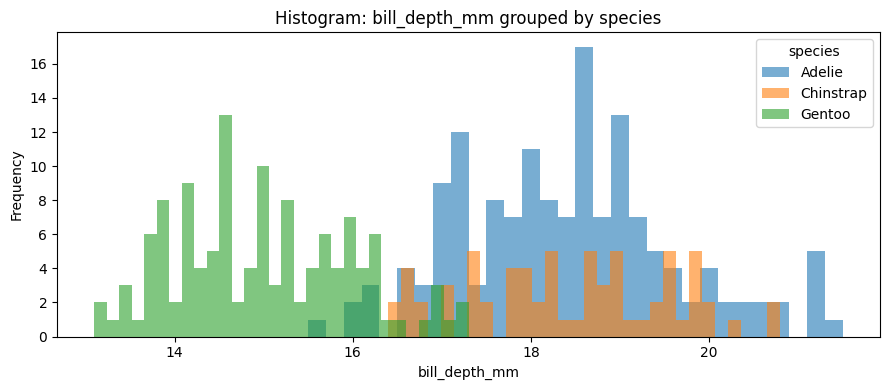

  ✓  artifacts\05_visual_registry.json


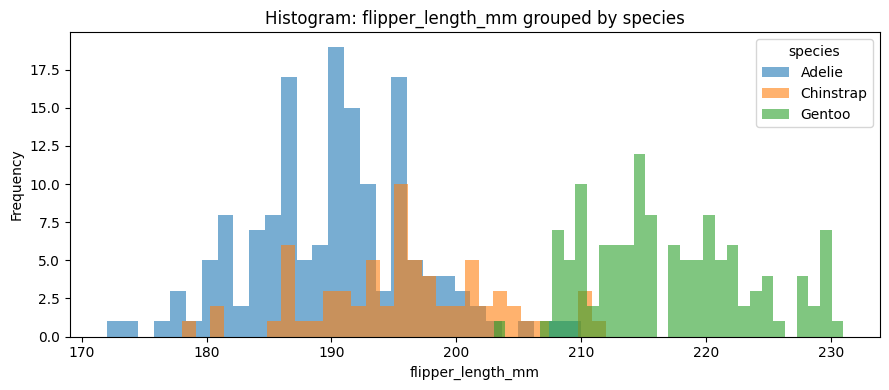

  ✓  artifacts\05_visual_registry.json


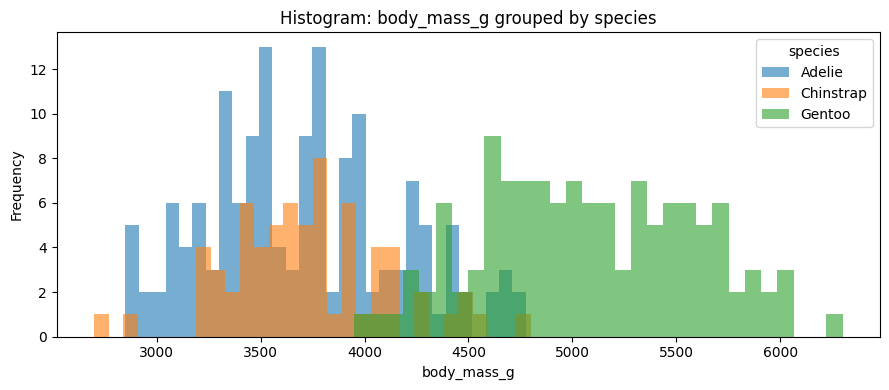

  ✓  artifacts\05_visual_registry.json


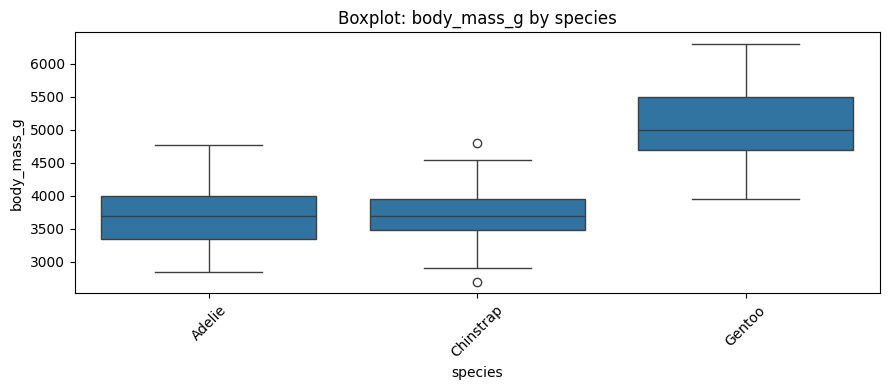

  ✓  artifacts\05_visual_registry.json


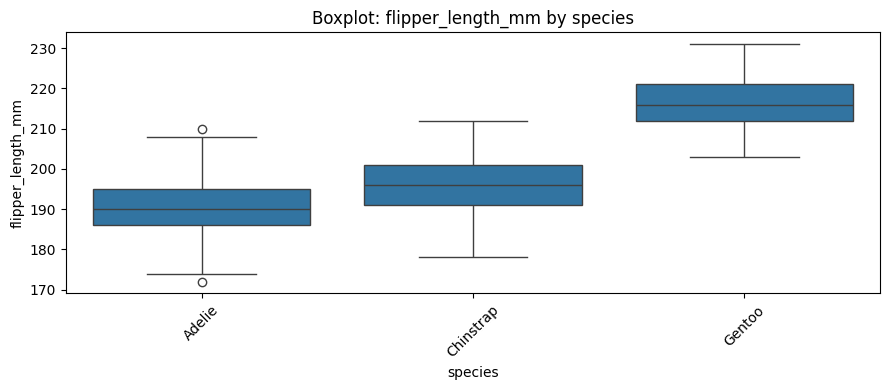

  ✓  artifacts\05_visual_registry.json


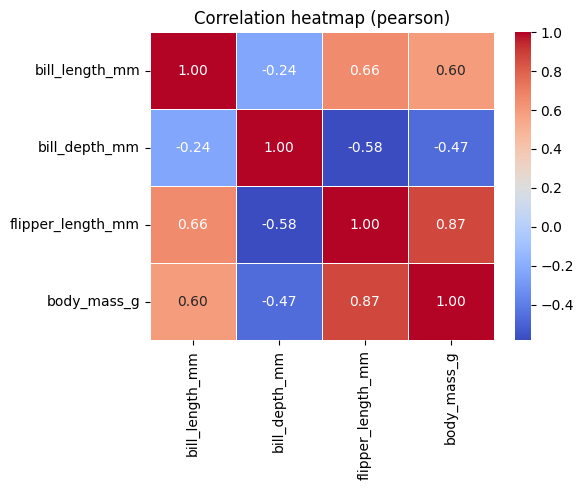

  ✓  artifacts\05_visual_registry.json


In [10]:
# ── Phase 2: DESCRIBE ─────────────────────────────────────────────────────────
numeric_summary(df)
categorical_summary(df)
correlation_matrix(df, method="pearson")
correlation_matrix(df, method="spearman")
crosstab(df, a="species", b="sex")
crosstab(df, a="species", b="island")
plot_count(df, x="species")
plot_count(df, x="island")
plot_count(df, x="sex")
plot_hist(df, x="bill_length_mm", groupby="species")
plot_hist(df, x="bill_depth_mm", groupby="species")
plot_hist(df, x="flipper_length_mm", groupby="species")
plot_hist(df, x="body_mass_g", groupby="species")
plot_box(df, x="species", y="body_mass_g")
plot_box(df, x="species", y="flipper_length_mm")
plot_heatmap_corr(df, method="pearson")

---
## Section 5 — Phase 3: HYPOTHESIZE & CONCLUDE

Share `artifacts/04_descriptive_stats.json` and `artifacts/05_visual_registry.json` with the Planner and say:  
> *

The Planner will write the hypothesis and conclusion artifacts directly.  
If it requests additional operations, paste them below.

In [11]:
# ── Phase 3: HYPOTHESIZE & CONCLUDE ──────────────────────────────────────────
required = ["04_descriptive_stats.json", "05_visual_registry.json"]
outputs = ["06_hypotheses_log.json", "07_conclusions.json", "report.md"]

missing_required = [f for f in required if not (ARTIFACTS / f).exists()]
if missing_required:
    raise FileNotFoundError(
        "Missing required artifacts for Phase 3: " + ", ".join(missing_required)
    )

print("Phase 3 prerequisites: OK")

for name in required + outputs:
    path = ARTIFACTS / name
    print(f"- {name}: {'OK' if path.exists() else 'MISSING'}")

for name in outputs:
    path = ARTIFACTS / name
    if path.exists():
        text = path.read_text(encoding="utf-8")
        preview = text if len(text) <= 1200 else text[:1200] + "\n... (truncated)"
        print(f"\n--- {name} ---\n{preview}")

print("\nIf any output is MISSING, ask the planner to regenerate Phase 3 artifacts.")

Phase 3 prerequisites: OK
- 04_descriptive_stats.json: OK
- 05_visual_registry.json: OK
- 06_hypotheses_log.json: OK
- 07_conclusions.json: OK
- report.md: OK

--- 06_hypotheses_log.json ---
{
  "hypotheses": [
    {
      "id": "H1",
      "origin": "ai_observer",
      "statement": "Flipper length is positively associated with body mass in the observed sample.",
      "variables": {
        "x": "flipper_length_mm",
        "y": "body_mass_g",
        "group": null
      },
      "suggested_tests": [
        "Pearson correlation",
        "Spearman correlation"
      ],
      "evidence_refs": [
        "04_descriptive_stats.json:correlation_matrices.pearson.flipper_length_mm.body_mass_g",
        "04_descriptive_stats.json:correlation_matrices.spearman.flipper_length_mm.body_mass_g",
        "05_visual_registry.json:heatmap_10"
      ],
      "decision_needed": "human"
    },
    {
      "id": "H2",
      "origin": "ai_observer",
      "statement": "Body mass distributions differ acr